# Phase 1 - neurone unique

Premier test : un seul neurone qui prédit si un point 2D est de classe 0 ou 1.
Pas d'entraînement ici, on fixe les poids à la main et on regarde ce que ça donne.

Formule du neurone : z = x1*w1 + x2*w2 + b, puis sigmoid(z) pour avoir une proba.

In [1]:
import numpy as np

X = np.array([
    [0.2, 0.1],
    [0.8, 0.9],
    [0.3, 0.7],
    [0.9, 0.2],
])
y = np.array([0, 1, 1, 0])

In [2]:
def sigmoid(x):
    # transforme n'importe quel nombre en valeur entre 0 et 1
    return 1 / (1 + np.exp(-x))

In [3]:
def forward(X, w, b):
    # somme pondérée puis activation
    z = np.dot(X, w) + b
    return sigmoid(z)

In [4]:
def compute_loss(y_true, y_pred):
    # Binary Cross-Entropy
    # clip pour éviter log(0) qui donne -inf
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [5]:
# poids fixés, pas encore d'entraînement
w = np.array([0.5, -0.3])
b = 0.1

y_pred = forward(X, w, b)
loss = compute_loss(y, y_pred)

print("Prédictions :", y_pred.round(3))
print("Étiquettes  :", y)
print(f"Loss BCE    : {loss:.4f}")

Prédictions : [0.542 0.557 0.51  0.62 ]
Étiquettes  : [0 1 1 0]
Loss BCE    : 0.7519


Les prédictions sont toutes autour de 0.5-0.6 : le neurone hésite sur tout, normal vu que les poids sont fixés au hasard. La loss est à ~0.75, c'est même pire qu'un modèle qui répondrait 0.5 partout (0.69). Il faudra la descente de gradient (phase 2) pour corriger les poids.

## Tests

**Cas limite : toutes les entrées à 0**

Si X = 0 alors z = b, donc le biais seul pilote la sortie. On doit avoir sigmoid(0.1) ≈ 0.525 partout.

In [6]:
X_zeros = np.zeros((4, 2))
pred_zeros = forward(X_zeros, w, b)

print("Prédictions :", pred_zeros.round(3))
print(f"sigmoid(b)  : {sigmoid(b):.3f}")
print(f"Loss        : {compute_loss(y, pred_zeros):.4f}")

Prédictions : [0.525 0.525 0.525 0.525]
sigmoid(b)  : 0.525
Loss        : 0.6944


**Scénario adversarial : poids et biais à 0**

Tout à zéro -> z = 0 -> sigmoid(0) = 0.5 partout, le réseau ne prédit rien.
La loss vaut -log(0.5) ≈ 0.693, c'est le pire point de départ possible (mais il apprendrait quand même avec une boucle d'entraînement).

In [7]:
w0 = np.zeros(2)
b0 = 0.0

pred_adv = forward(X, w0, b0)

print("Prédictions :", pred_adv.round(3))
print(f"Loss        : {compute_loss(y, pred_adv):.4f}")
print(f"-log(0.5)   : {-np.log(0.5):.4f}")

Prédictions : [0.5 0.5 0.5 0.5]
Loss        : 0.6931
-log(0.5)   : 0.6931


# Phase 2 - descente de gradient

On ajoute la boucle d'entraînement : à chaque epoch le neurone corrige ses poids dans la direction qui fait baisser la loss.

Pour un neurone sigmoid avec la BCE, le gradient se simplifie bien (chain rule) :
- dL/dw = (1/n) * X.T @ (y_pred - y)
- dL/db = moyenne(y_pred - y)

On réutilise sigmoid, forward et compute_loss de la phase 1. Cette fois les poids partent aléatoires (petits, seed fixée pour la reproductibilité) et c'est le gradient qui les corrige.

In [8]:
import matplotlib.pyplot as plt

np.random.seed(42)
w = np.random.randn(2) * 0.01   # petits poids aléatoires pour briser la symétrie
b = 0.0
learning_rate = 0.1
n_epochs = 200
losses = []

for epoch in range(n_epochs):
    # forward
    y_pred = forward(X, w, b)
    loss = compute_loss(y, y_pred)
    losses.append(loss)

    # gradient (simplification BCE + sigmoid)
    error = y_pred - y
    dw = X.T @ error / len(y)
    db = error.mean()

    # descente de gradient : un pas dans le sens opposé au gradient
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w.round(3)} | b: {b:.3f}")

print(f"Loss finale : {losses[-1]:.4f}")

Epoch   0 | Loss: 0.6934 | w: [0.005 0.015] | b: -0.000
Epoch  40 | Loss: 0.6074 | w: [-0.054  0.585] | b: -0.098
Epoch  80 | Loss: 0.5396 | w: [-0.149  1.07 ] | b: -0.257
Epoch 120 | Loss: 0.4828 | w: [-0.245  1.508] | b: -0.417
Epoch 160 | Loss: 0.4348 | w: [-0.335  1.909] | b: -0.565
Loss finale : 0.3951


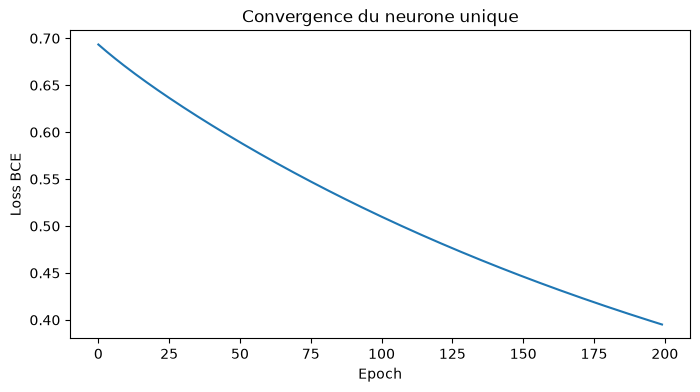

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss BCE")
plt.title("Convergence du neurone unique")
plt.savefig("phase2_loss_curve.png", dpi=100, bbox_inches='tight')
plt.show()

La loss part de 0.69 (poids quasi nuls -> prédictions ~0.5, cf phase 1) et descend régulièrement jusqu'à ~0.39.

Note : l'énoncé arrive à ~0.4 en 50 epochs seulement. En creusant, ses valeurs correspondent à un gradient sommé sur le batch (sans le 1/n), ce qui revient à un learning rate 4x plus grand. J'ai gardé la formule avec la moyenne (celle donnée dans le cours) donc il me faut ~200 epochs pour arriver au même point : même chemin, pas plus petits.

## Tests

Je remets la boucle dans une fonction pour tester d'autres learning rates sans copier-coller.

**Cas limite : learning_rate = 0** -> les poids ne bougent jamais, la loss non plus. Si un jour ma courbe ne descend pas, c'est la première chose à vérifier.

In [10]:
def train(lr, n_epochs=200):
    np.random.seed(42)
    w = np.random.randn(2) * 0.01
    b = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_pred = forward(X, w, b)
        losses.append(compute_loss(y, y_pred))
        error = y_pred - y
        w -= lr * (X.T @ error) / len(y)
        b -= lr * error.mean()
    return losses

losses_0 = train(lr=0)
print(f"lr=0 : loss epoch 0 = {losses_0[0]:.4f} | loss epoch 199 = {losses_0[-1]:.4f}")

lr=0 : loss epoch 0 = 0.6934 | loss epoch 199 = 0.6934


**Scénario adversarial : learning_rate = 10**

Les pas sont énormes, on saute par-dessus le minimum au lieu de descendre tranquillement vers lui.

In [11]:
losses_10 = train(lr=10.0)
print("10 premières loss :", np.round(losses_10[:10], 4))
print(f"lr=10  : loss finale = {losses_10[-1]:.4f}")
print(f"lr=0.1 : loss finale = {losses[-1]:.4f}")

10 premières loss : [0.6934 0.5326 0.597  1.0224 0.7579 0.8841 0.2941 0.1665 0.0753 0.0695]
lr=10  : loss finale = 0.0060
lr=0.1 : loss finale = 0.3951


Avec lr=10 le début est chaotique : la loss fait 0.69 -> 0.53 -> 0.60 -> 1.02 -> 0.76... elle remonte au lieu de descendre, chaque pas saute par-dessus le minimum. Sur ce mini dataset de 4 points (séparable) elle finit quand même par tomber très bas, mais sur un vrai problème ce comportement diverge — c'est exactement ce qu'on verra en phase 7 sur MNIST. Le learning rate est le premier hyperparamètre à régler.